# pandas 快速入门

pandas 是 Python 里最常用的数据处理库，核心就两个数据结构：

- **Series**：一维的、带标签的数组，可以理解成「带索引的一列数据」。
- **DataFrame**：二维的表格，由多个 Series 拼起来，类似 Excel 表格或 SQL 表。

这份 Notebook 会从这两个结构讲起，然后演示最常用的操作：读取数据、筛选、处理缺失值、分组统计。所有示例都可以直接运行，跟着改改数字就能玩起来。

In [1]:
# 检查 pandas 是否已安装，并打印版本
try:
    import pandas as pd
    print("pandas 已安装，版本：", pd.__version__)
except ImportError:
    %pip install -q pandas
    import pandas as pd
    print("pandas 安装完成，版本：", pd.__version__)

pandas 已安装，版本： 3.0.5


## 认识 Series

Series 是一维的、带索引的数组。它像 Python 列表，但每个元素都挂着一个「标签」（index），可以按标签取值，也可以按位置取值。

下面创建一个 Series，观察它的值、索引和数据类型。

In [2]:
import pandas as pd

# 用列表创建 Series，index 是自定义的标签
s = pd.Series([1, 3, 5, 7, 9], index=["a", "b", "c", "d", "e"])
print(s)
print("\n索引（index）：", list(s.index))
print("值（values）：", list(s.values))
print("数据类型（dtype）：", s.dtype)

# 按标签取值
print("\n按标签取 s['c']：", s["c"])
# 按位置取值
print("按位置取 s.iloc[0]：", s.iloc[0])

a    1
b    3
c    5
d    7
e    9
dtype: int64

索引（index）： ['a', 'b', 'c', 'd', 'e']
值（values）： [np.int64(1), np.int64(3), np.int64(5), np.int64(7), np.int64(9)]
数据类型（dtype）： int64

按标签取 s['c']： 5
按位置取 s.iloc[0]： 1


## 创建 DataFrame

DataFrame 是二维表格，最常见的是用「字典」创建：字典的 key 是列名，value 是该列的数据。创建后可以用 `shape` 看行列数、`head()` 看前几行、`info()` 看每列的类型和缺失情况。

In [3]:
import pandas as pd

# 用字典创建：key 是列名，value 是这一列的数据
data = {
    "姓名": ["张三", "李四", "王五", "赵六"],
    "年龄": [23, 30, 35, 28],
    "城市": ["北京", "上海", "广州", "深圳"],
    "月薪": [8000, 12000, 9500, 11000],
}
df = pd.DataFrame(data)
print(df)

print("\n形状（行, 列）：", df.shape)
print("\n各列信息：")
df.info()

   姓名  年龄  城市     月薪
0  张三  23  北京   8000
1  李四  30  上海  12000
2  王五  35  广州   9500
3  赵六  28  深圳  11000

形状（行, 列）： (4, 4)

各列信息：
<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   姓名      4 non-null      str  
 1   年龄      4 non-null      int64
 2   城市      4 non-null      str  
 3   月薪      4 non-null      int64
dtypes: int64(2), str(2)
memory usage: 260.0 bytes


## 读取 CSV 文件

实际工作中数据大多存在文件里。`pd.read_csv()` 是最常用的入口，日常是直接传文件路径 `pd.read_csv("data.csv")`。这里用 `StringIO` 模拟一个 CSV 文件内容，方便在 Notebook 里直接运行。

另外 pandas 还能读 Excel（`read_excel`）、JSON（`read_json`）等，用法类似。

In [4]:
import pandas as pd
from io import StringIO

# 模拟一个 CSV 文件的内容（真实使用时改成 pd.read_csv("data.csv")）
csv_content = """姓名,年龄,城市,月薪
张三,23,北京,8000
李四,30,上海,12000
王五,35,广州,9500
赵六,28,深圳,11000
"""
df = pd.read_csv(StringIO(csv_content))
print(df)

# 也演示一下把 DataFrame 导出成 CSV（真实使用时会写到磁盘文件）
df.to_csv("员工表.csv", index=False)
print("\n已导出到 员工表.csv（index=False 表示不写行号）")

   姓名  年龄  城市     月薪
0  张三  23  北京   8000
1  李四  30  上海  12000
2  王五  35  广州   9500
3  赵六  28  深圳  11000

已导出到 员工表.csv（index=False 表示不写行号）


## 选取数据：列、行、单元格

pandas 里取数据有三套常用方式：

- `df["列名"]`：取一列，返回 Series；`df[["列1", "列2"]]` 取多列。
- `df.loc[行标签, 列标签]`：按**标签**定位。
- `df.iloc[行位置, 列位置]`：按**位置（从 0 数）**定位。

记住 `loc` 用名字、`iloc` 用序号，就不会混。

In [5]:
import pandas as pd
from io import StringIO

csv_content = """姓名,年龄,城市,月薪
张三,23,北京,8000
李四,30,上海,12000
王五,35,广州,9500
赵六,28,深圳,11000
"""
df = pd.read_csv(StringIO(csv_content))

# 取一列（Series）
print("取一列「年龄」：")
print(df["年龄"])
print("\n取两列：")
print(df[["姓名", "城市"]])

# 按标签定位 loc
print("\nloc[0, '姓名']（第 0 行的姓名）：", df.loc[0, "姓名"])
print("\nloc 取多行多列：")
print(df.loc[1:3, ["姓名", "月薪"]])

# 按位置定位 iloc
print("\niloc[0, 0]（第 1 行第 1 列）：", df.iloc[0, 0])
print("\niloc 取前两行、所有列：")
print(df.iloc[:2, :])

取一列「年龄」：
0    23
1    30
2    35
3    28
Name: 年龄, dtype: int64

取两列：
   姓名  城市
0  张三  北京
1  李四  上海
2  王五  广州
3  赵六  深圳

loc[0, '姓名']（第 0 行的姓名）： 张三

loc 取多行多列：
   姓名     月薪
1  李四  12000
2  王五   9500
3  赵六  11000

iloc[0, 0]（第 1 行第 1 列）： 张三

iloc 取前两行、所有列：
   姓名  年龄  城市     月薪
0  张三  23  北京   8000
1  李四  30  上海  12000


## 按条件筛选行

筛选的本质是构造一个「布尔序列」：每个元素是 True/False，表示这一行是否保留。

常用写法是 `df[df["列"] > 阈值]`。多个条件用 `&`（与）、`|`（或）连接，**每个条件都要加括号**。

比较运算符包括 `>`、`<`、`>=`、`<=`、`==`、`!=`，字符串判断常用 `.isin()` 或 `.str.contains()`。

In [6]:
import pandas as pd
from io import StringIO

csv_content = """姓名,年龄,城市,月薪
张三,23,北京,8000
李四,30,上海,12000
王五,35,广州,9500
赵六,28,深圳,11000
"""
df = pd.read_csv(StringIO(csv_content))

# 单个条件：年龄大于 25
print("年龄 > 25 的人：")
print(df[df["年龄"] > 25])

# 多个条件：月薪 >= 10000 且 城市不是上海
print("\n月薪 >= 10000 且城市不是上海的人：")
print(df[(df["月薪"] >= 10000) & (df["城市"] != "上海")])

# 用 isin 判断是否属于某个集合
print("\n城市在 ['北京', '深圳'] 的人：")
print(df[df["城市"].isin(["北京", "深圳"])])

年龄 > 25 的人：
   姓名  年龄  城市     月薪
1  李四  30  上海  12000
2  王五  35  广州   9500
3  赵六  28  深圳  11000

月薪 >= 10000 且城市不是上海的人：
   姓名  年龄  城市     月薪
3  赵六  28  深圳  11000

城市在 ['北京', '深圳'] 的人：
   姓名  年龄  城市     月薪
0  张三  23  北京   8000
3  赵六  28  深圳  11000


## 处理缺失值

缺失值在 pandas 里用 `NaN` 表示。处理流程一般是：先看有没有、有多少，再决定「删」还是「填」。

- `isna()` / `notna()`：判断是否缺失。
- `dropna()`：删除含缺失值的行（或列）。
- `fillna()`：用指定值填充，比如均值、中位数、0。

下面造一个带缺失值的小表来演示。

In [7]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "姓名": ["张三", "李四", "王五", "赵六"],
    "年龄": [23, np.nan, 35, 28],
    "月薪": [8000, 12000, np.nan, 11000],
})
print("原始数据：")
print(df)

print("\n哪些位置缺失（True 表示缺失）：")
print(df.isna())

print("\n每列缺失个数：")
print(df.isna().sum())

print("\n删除含缺失值的行（dropna）：")
print(df.dropna())

print("\n用中位数填充年龄、用均值填充月薪（fillna）：")
print(df.fillna({"年龄": df["年龄"].median(), "月薪": df["月薪"].mean()}))

原始数据：
   姓名    年龄       月薪
0  张三  23.0   8000.0
1  李四   NaN  12000.0
2  王五  35.0      NaN
3  赵六  28.0  11000.0

哪些位置缺失（True 表示缺失）：
      姓名     年龄     月薪
0  False  False  False
1  False   True  False
2  False  False   True
3  False  False  False

每列缺失个数：
姓名    0
年龄    1
月薪    1
dtype: int64

删除含缺失值的行（dropna）：
   姓名    年龄       月薪
0  张三  23.0   8000.0
3  赵六  28.0  11000.0

用中位数填充年龄、用均值填充月薪（fillna）：
   姓名    年龄            月薪
0  张三  23.0   8000.000000
1  李四  28.0  12000.000000
2  王五  35.0  10333.333333
3  赵六  28.0  11000.000000


## 分组与聚合（groupby）

`groupby` 把数据按某列的值分成若干组，然后对每组做聚合（求和、求均值、计数等），效果等价于 SQL 的 `GROUP BY`。

常用套路：`df.groupby("分组列")["数值列"].agg(["mean", "sum", "count"])`。

下面造一张销售记录表，按「城市」分组统计销售情况。

In [8]:
import pandas as pd

sales = pd.DataFrame({
    "城市": ["北京", "上海", "北京", "广州", "上海", "北京"],
    "产品": ["A", "A", "B", "B", "A", "B"],
    "销量": [100, 150, 80, 60, 200, 90],
    "单价": [10, 10, 20, 20, 10, 20],
})
print("销售记录：")
print(sales)

# 先算一列「销售额」= 销量 * 单价
sales["销售额"] = sales["销量"] * sales["单价"]

print("\n按城市分组的销售汇总：")
print(sales.groupby("城市")["销售额"].agg(["sum", "mean", "count"]))

print("\n按城市和产品双重分组：")
print(sales.groupby(["城市", "产品"])["销量"].sum())

销售记录：
   城市 产品   销量  单价
0  北京  A  100  10
1  上海  A  150  10
2  北京  B   80  20
3  广州  B   60  20
4  上海  A  200  10
5  北京  B   90  20

按城市分组的销售汇总：
     sum         mean  count
城市                          
上海  3500  1750.000000      2
北京  4400  1466.666667      3
广州  1200  1200.000000      1

按城市和产品双重分组：
城市  产品
上海  A     350
北京  A     100
    B     170
广州  B      60
Name: 销量, dtype: int64


## 快速画图

DataFrame 自带 `.plot()` 方法，底层是 matplotlib，不用先学绘图库也能快速看数据分布。`kind` 参数可选 `bar`、`line`、`pie`、`scatter` 等。

下面把上一节按城市汇总的销售额画成柱状图。

各城市销售总额：
城市
上海    3500
北京    4400
广州    1200
Name: 销售额, dtype: int64


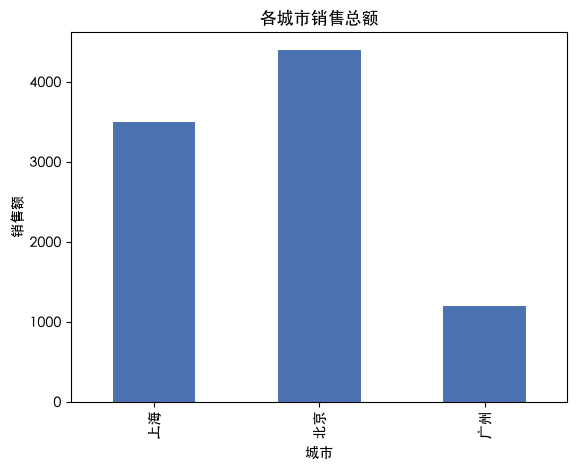

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

sales = pd.DataFrame({
    "城市": ["北京", "上海", "北京", "广州", "上海", "北京"],
    "产品": ["A", "A", "B", "B", "A", "B"],
    "销量": [100, 150, 80, 60, 200, 90],
    "单价": [10, 10, 20, 20, 10, 20],
})
sales["销售额"] = sales["销量"] * sales["单价"]

city_sum = sales.groupby("城市")["销售额"].sum()
print("各城市销售总额：")
print(city_sum)

city_sum.plot(kind="bar", title="各城市销售总额", color="#4C72B0")
plt.ylabel("销售额")
plt.show()

## 小结

这份 Notebook 用一套从零开始的小例子走完了 pandas 最常用的流程：

1. **Series / DataFrame**：两个核心数据结构，前者是一维带标签数组，后者是二维表格。
2. **读写文件**：`read_csv` / `to_csv` 是最常用的入口和出口，Excel、JSON 同理。
3. **选取数据**：取列用 `df["列"]`，按标签用 `loc`，按位置用 `iloc`。
4. **条件筛选**：`df[df["列"] > 阈值]`，多条件用 `&`、`|` 且要加括号。
5. **缺失值**：`isna()` 查看、`dropna()` 删除、`fillna()` 填充。
6. **分组统计**：`groupby(...).agg(...)`，等价于 SQL 的 `GROUP BY`。
7. **快速画图**：`.plot()` 一行出图，方便数据探索。

**建议的下一步**：拿一份真实的 CSV（比如网上公开的数据集）练一遍——先 `read_csv` 读进来，`info()` 和 `describe()` 看概貌，筛选出感兴趣的子集，按某个维度 `groupby` 汇总，最后画图。遇到拿不准的函数，查官方文档（pandas 的 API reference 非常详细）或直接 `help(pd.read_csv)`。

局限：本教程覆盖的是「日常 80%」的用法，像 `merge`（表连接）、`pivot_table`（透视表）、时间序列、`apply`（自定义函数）等进阶内容没有展开，需要时可以单独再学。